# TD（Temporal Difference）算法（时序差分）

> TD / SARSA 与蒙特卡洛（MC）的核心对比如下：
>
> ---

| | TD / SARSA | 蒙特卡洛（MC） |
|---|---|---|
| **更新时机** | **增量 / 在线**：拿到 $(s, r, s')$ 立刻改 | **非增量 / 回合结束才改**：必须算完整 $G$ |
| **任务类型** | 回合制和持续任务都能做 | 只能做有终止的回合制任务 |
| **自举（Bootstrap）** | **要自举**：用旧的 $V$ 或 $Q$ 当目标的一部分，所以依赖初値 | **不自举**：目标就是这条轨迹的真实回报 $G$ |
| **方差** | 低：SARSA 估 $Q(s_t, a_t)$ 只涉及 $R_{t+1}, S_{t+1}, A_{t+1}$ 三个随机量 | 高：整条 $R_{t+1} + \gamma R_{t+2} + \cdots$；长度 $L$，每格 $A$ 个动作时可能轨迹有 $A^L$ 条 |
| **偏差** | 有：初値不准会渗进目标；数据多了偏差会消掉 | 无偏：期望就是真値 |

> ---

## 一、TD 方法估计状态价值（State Value）

### 1.1 环境与策略初始化

In [1]:
# 导入 NumPy 库，用于数组操作、矩阵运算等
import numpy as np
# 导入 random 模块，用于随机选择初始状态和动作
import random
# 导入 importlib 标准库，用于按文件路径动态加载模块
import importlib.util
# 导入 os 模块，用于拼接当前目录与文件名
import os
# 导入 Jupyter 显示控制函数，用于在训练过程中清除输出以实时展示
from IPython.display import clear_output

# 由于环境文件名 "02.1.ModelFree_Env_GridWorldV2.py" 以数字开头，
# Python 无法直接 import，需通过 importlib 按路径加载
_env_path = os.path.join(os.path.dirname(os.path.abspath("__file__")),
                         "02.1.ModelFree_Env_GridWorldV2.py")  # 环境文件的绝对路径（str）
_spec = importlib.util.spec_from_file_location("GridWorld_v2", _env_path)  # 构造模块规格对象
GridWorld_v2 = importlib.util.module_from_spec(_spec)  # 根据规格创建模块对象
_spec.loader.exec_module(GridWorld_v2)                  # 执行模块代码，完成加载

In [2]:
# 设置网格世界行数（必须与 desc 字符串的行数保持一致）
rows = 5
# 设置网格世界列数（必须与 desc 字符串每行的字符数保持一致）
columns = 5
# 创建 GridWorld 环境实例
# forbiddenAreaScore=-5000: 进入禁止区域（'#'）的即时奖励（惩罚）
# score=100: 到达目标格（'T'）的即时奖励
# desc: 地图描述字符串列表，'.'=普通格，'#'=障碍格，'T'=目标格
gridworld = GridWorld_v2.GridWorld_v2(
    forbiddenAreaScore=-5000, score=100,
    desc=[".....", ".##..", "..#..", ".#T#.", ".#..."])

# 显示网格世界地图（'⬜'=普通格，'🚫'=障碍，'✅'=目标）
gridworld.show()

# 生成随机初始策略（独热编码形式）
# np.random.randint(0,5, size=(rows*columns,))：为 25 个状态各随机选一个动作索引，shape (25,)
# np.eye(5)[...]：将整数索引转为独热向量，shape (25, 5)
# 策略矩阵 shape: (25, 5)——行=状态索引[0~24]，列=5种动作[上下左右原地]的概率（独热=确定性策略）
policy = np.eye(5)[np.random.randint(0, 5, size=(rows * columns))]
# 可视化当前策略（显示每格的动作方向箭头）
gridworld.showPolicy(policy)

⬜️⬜️⬜️⬜️⬜️
⬜️🚫🚫⬜️⬜️
⬜️⬜️🚫⬜️⬜️
⬜️🚫✅🚫⬜️
⬜️🚫⬜️⬜️⬜️
🔄⬅️⬇️➡️⬆️
🔄⏫️🔄➡️⬆️
⬇️⬅️🔄⬇️⬆️
➡️⏩️✅🔄🔄
⬅️⏬➡️➡️⬇️


### 1.2 随机策略下生成轨迹集合

In [3]:
# 创建均匀随机策略：每个状态对 5 种动作各有 0.2 的概率
# shape: (25, 5)——行=状态索引[0~24]，列=5种动作的选择概率（均为 0.2）
policy = 0.2 * np.ones((rows * columns, 5))

# 生成 500 条轨迹并计算每步得分
# 每条轨迹：随机选取初始状态（0~24）和初始动作（0~4），按策略执行 500 步
# 返回值 episodes：列表，长度 500，每个元素是一条轨迹
#   每条轨迹：元组列表，每个元组为 (当前状态, 动作, 即时奖励, 下一状态, 下一动作)
#   元组中各元素类型：(int, int, float, int, int)
episodes = [
    gridworld.getTrajectoryScore(
        nowState=random.randint(0, 24),   # 随机初始状态（0~24 的整数）
        action=random.randint(0, 4),       # 随机初始动作（0~4 的整数）
        policy=policy,                     # 使用均匀随机策略
        steps=500)                         # 每条轨迹最多 500 步
    for i in range(500)                    # 共生成 500 条轨迹
]

### 1.3 TD 更新状态价值

> TD(0) 的价值更新本质是 **Robbins-Monro（RM）随机近似**算法的应用。
>
> **RM 一般形式**——求解 $\mathbb{E}[g(\theta)] = 0$ 的迭代格式：
>
> $$\theta_{k+1} = \theta_k - \alpha_k \cdot g(\theta_k, \eta_k)$$
>
> **对应到 TD(0)**——目标是找到满足贝尔曼期望方程 $\mathbb{E}\bigl[V(s_t) - (r_{t+1} + \gamma V(s_{t+1}))\bigr] = 0$ 的不动点，令 $g = V(s_t) - (r_{t+1} + \gamma V(s_{t+1}))$ 代入，得：
>
> $$V(s_t) \leftarrow V(s_t) - \alpha \cdot \underbrace{\bigl[V(s_t) - (r_{t+1} + \gamma V(s_{t+1}))\bigr]}_{\text{TD 误差（单样本噪声观测）}}$$
>
> 三者的对应关系如下：
>
> ---

| RM 符号 | TD 中的含义 |
|---|---|
| $\theta_k$ | `state_value[tmpstate]`，即 $V(s_t)$ 的当前估计 |
| $g(\theta_k, \eta_k)$ | `TD_error`，即单步采样的含噪观测，期望为零时恰好满足贝尔曼方程 |
| $\alpha_k$ | `learning_rate`，即步长 |

> ---
>
> 因此，TD(0) 本质上是用 RM 算法求解贝尔曼期望方程的不动点，每次以**单个样本**代替期望，构成有噪声的随机迭代。

> **TD(0) 中“0”的含义：n-step TD 家族**
>
> TD 是一系列方法，核心区别在于用多少步的**真实奖励**来构造更新目标。**“0”表示额外看真实奖励 0 步**——第 1 步的奖励是真实的，之后全靠 $V(s_{t+1})$ 这个**估计值** Bootstrap（自举）出来。
>
> ---

| 方法 | 更新目标 | 说明 |
|---|---|---|
| **TD(0)** | $r_{t+1} + \gamma V(s_{t+1})$ | 走 1 步，立刻用 $V(s_{t+1})$ 估计剩余 |
| **2-step TD** | $r_{t+1} + \gamma r_{t+2} + \gamma^2 V(s_{t+2})$ | 走 2 步再估计 |
| **n-step TD** | $\sum_{k=0}^{n-1}\gamma^k r_{t+k+1} + \gamma^n V(s_{t+n})$ | 走 n 步再估计 |
| **Monte Carlo** | $\sum_{k=0}^{T-t-1}\gamma^k r_{t+k+1}$（完整轨迹） | 走到终点，不 Bootstrap，全用真实值 |

> ---
>
> **Bootstrap（自举）**是指用**自身的估计值** $V(s_{t+1})$ 来更新另一个估计值 $V(s_t)$，就像“用自己的靴带把自己提起来”。n 越小，Bootstrap 成分越重，偏差（Bias）越大、方差（Variance）越小；n 越大，越接近 Monte Carlo，偏差越小、方差越大。

In [4]:
# 随机初始化状态价值向量
# shape: (25,)——每个元素对应一个状态（0~24）的初始价值估计（随机标准正态值）
state_value = np.random.randn(25)

# 学习率（TD 更新步长），控制每次误差修正的幅度
learning_rate = 0.01
# 折扣因子，衡量未来奖励的重要程度（0=只看当前奖励，1=长远眼光）
gamma = 0.99

# 外层循环：遍历 500 条轨迹（每条对应随机初始状态和动作的采样路径）
for i in range(500):
    # 内层循环：遍历第 i 条轨迹的每一步转移
    for trajectory in episodes[i]:
        # 解包当前步的转移元组
        # tmpstate: 当前状态索引 int
        # tmpaction: 当前动作索引 int
        # tmpscore: 即时奖励 float
        # nextState: 下一状态索引 int
        # nextAction: 下一动作索引 int（TD(0) 中暂不使用）
        tmpstate, tmpaction, tmpscore, nextState, nextAction = trajectory

        # TD 误差（Temporal Difference Error）= V(s_t) - [r_{t+1} + γ * V(s_{t+1})]
        # 正值表示当前估计偏高，负值表示当前估计偏低
        TD_error = state_value[tmpstate] - (tmpscore + gamma * state_value[nextState])

        # 按 TD 误差更新当前状态的价值估计（朝减小误差的方向修正）
        state_value[tmpstate] = state_value[tmpstate] - learning_rate * TD_error

### 1.4 结果展示与三维可视化

In [5]:
# 对状态价值向量进行四舍五入（保留 3 位小数）并重塑为 5×5 矩阵
# 输入 shape: (25,) —— 25 个状态的价值
# 输出 shape: (5, 5) —— 对应网格地图的二维布局（行=网格行，列=网格列）
state_value = np.round(state_value, decimals=3).reshape(5, 5)

In [6]:
# 显示状态价值矩阵（shape (5, 5)，每个元素是对应格子的状态价值估计）
state_value

array([[-69661.234, -72185.873, -71109.866, -66214.544, -62641.882],
       [-73169.391, -76596.106, -76768.562, -71092.675, -65039.044],
       [-74599.479, -79458.026, -78511.908, -73936.541, -67418.707],
       [-76736.646, -79484.539, -79107.39 , -73546.274, -69158.992],
       [-77372.835, -78865.621, -76144.99 , -72578.175, -67920.263]])

In [7]:
# 导入 Matplotlib 3D 绘图工具
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

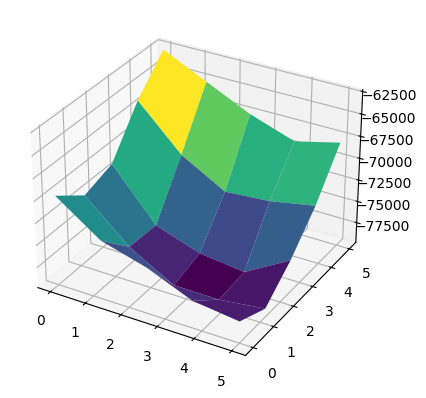

In [8]:
# 生成 x 和 y 轴坐标，对应网格的列索引和行索引
x = np.linspace(0, 5, 5)  # 5 个列坐标，shape (5,)
y = np.linspace(0, 5, 5)  # 5 个行坐标，shape (5,)

# 生成网格坐标矩阵，用于 3D 曲面绘制
# X, Y 的 shape 均为 (5, 5)
X, Y = np.meshgrid(x, y)

# 创建三维图形对象
fig = plt.figure()
# 添加 3D 子图（projection='3d' 指定三维投影）
ax = fig.add_subplot(111, projection='3d')
# 绘制状态价值的三维曲面图
# Y 对应行（y 轴），X 对应列（x 轴），state_value 对应高度（z 轴）
# cmap='viridis'：使用 viridis 颜色映射，颜色越深表示价值越低
ax.plot_surface(Y, X, state_value, cmap='viridis')

## 二、利用 TD 拟合状态价值、推导动作价值并更新策略

### 2.1 超参数设置

In [ ]:
# 折扣因子（越接近 1 越有长远眼光，越接近 0 越短视）
gamma = 0.999
# 每条轨迹的最大步数（步数越多，探索越充分）
trajectorySteps = 20000
# TD 学习率（控制状态价值更新的步长）
learning_rate = 0.01
# 总训练轮数（每轮产生一条新轨迹并更新价值和策略）
num_episodes = 6000

### 2.2 初始化策略、状态价值与 Q 表

In [ ]:
# 初始化随机确定性策略（独热编码）
# np.random.randint(0,5, size=(rows*columns,))：25 个状态各随机选一个动作，shape (25,)
# np.eye(5)[...]：转为独热向量，shape (25, 5)——每行只有一个 1
policy = np.eye(5)[np.random.randint(0, 5, size=(rows * columns))]

# 初始化状态价值向量（全零）
# shape: (25,)——每个元素对应一个状态（0~24）的价值估计
state_value = np.zeros((rows * columns))

# 初始化 Q 表（动作价值矩阵，全零）
# shape: (25, 5)——行=状态索引[0~24]，列=5种动作[上下左右原地]的 Q 值
qtable = np.zeros((rows * columns, 5))

In [ ]:
# 显示网格地图和当前随机策略
gridworld.show()             # 显示地图（障碍和目标位置）
gridworld.showPolicy(policy) # 显示每个格子的当前动作方向
print("random policy")       # 打印提示：当前为随机初始策略

⬜️⬜️⬜️⬜️⬜️
⬜️🚫🚫⬜️⬜️
⬜️⬜️🚫⬜️⬜️
⬜️🚫✅🚫⬜️
⬜️🚫⬜️⬜️⬜️
➡️⬇️⬇️⬇️➡️
⬅️⏩️🔄⬅️➡️
⬅️⬇️⏪⬇️🔄
⬅️⏩️✅⏩️⬆️
⬇️⏬⬅️⬇️⬅️
random policy


### 2.3 TD 算法主训练循环（类 SARSA 结构）

In [ ]:
# 通过采样方法计算动作价值（Model-Free）
# 不知道环境的转移概率，无法直接用贝尔曼方程求解，只能通过交互采样估计

# 初始化探索率 epsilon（从 1 开始，表示完全随机探索）
epsilon = 1

for episode in range(num_episodes):  # 外层循环：遍历每个训练轮次
    # 线性衰减 epsilon（每轮减少 0.0001，最小保留 0.0001 的随机探索）
    if epsilon > 0.0001:
        epsilon -= 0.0001  # 逐渐减少探索，增加利用
    else:
        epsilon = 0.0001   # 确保 epsilon 不低于最小值

    # 计算 epsilon-greedy 策略中各动作的选取概率（5 个动作）
    # 推导：以概率 (1-ε) 直接选贪心动作，以概率 ε 均匀随机选 5 个动作之一（含贪心动作本身）
    # p1 = P(贪心动作)
    #     = (1 - ε)        # 直接选贪心动作的概率
    #     + ε * (1/5)      # 随机探索时恰好选中贪心动作的概率
    #     = 1 - ε + ε/5
    #     = 1 - 4ε/5
    #     = 1 - ε * (4/5)
    p1 = 1 - epsilon * (4/5)  # 贪心动作被选中的概率（float）
    # p0 = P(任意一个非贪心动作)
    #     = ε * (1/5)      # 随机探索时选中该动作的概率，共 4 个非贪心动作均等
    #     = ε / 5
    # 验证：p1 + 4 * p0 = (1 - 4ε/5) + 4*(ε/5) = 1 - 4ε/5 + 4ε/5 = 1 ✓
    p0 = epsilon / 5  # 非贪心动作被选中的概率（float）
    print(f"epision:{epsilon}, p1:{p1}, p0:{p0}")  # 打印当前探索参数

    # 构建概率映射字典：策略矩阵中 1（贪心动作）映射 p1，0（其他）映射 p0
    d = {1: p1, 0: p0}
    # 将确定性策略矩阵（独热）转为 epsilon-greedy 概率分布矩阵
    # shape: (25, 5)——每行为一个状态的动作概率分布
    policy_epsilon = np.vectorize(d.get)(policy)

    # 随机选择初始状态（0~24 中的整数）
    i = random.randint(0, 24)
    # 随机选择初始动作（0~4 中的整数）
    j = random.randint(0, 4)

    # 初始化状态访问计数器（长度 25 的列表，每个元素对应一个状态的访问次数）
    cnt = [0 for i in range(25)]

    # 按 epsilon-greedy 策略从初始状态 i 出发，执行初始动作 j，生成一条轨迹
    # 返回值：轨迹列表，每个元素为 (状态, 动作, 奖励, 下一状态, 下一动作) 的五元组
    Trajectory = gridworld.getTrajectoryScore(
        nowState=i, action=j,
        policy=policy_epsilon,
        steps=trajectorySteps,
        stop_when_reach_target=True)  # 到达目标格后自动停止

    # 在轨迹末尾追加目标格（状态17）的自循环转移，设计原因如下：
    # ① 状态17 不出现在 tmpstate 中：
    #   轨迹由 stop_when_reach_target=True 生成，到达状态17 后立即停止。
    #   轨迹最后一个元素形如 (..., some_state, action, reward, nextState=17, ...)，
    #   状态17 只作为 nextState，从未作为 tmpstate，反向 TD 更新的「起点」不完整。
    # ② 自循环锚定终止状态价值：
    #   反向更新到该元素时：
    #     TD_error = state_value[17] - (1 + γ * state_value[17])
    #              = 100 - (1 + 0.999 * 100) = 100 - 100.9 = -0.9（误差极小）
    #   误差接近 0，说明状态17 的价值与「得奖励1后留在状态17」高度自洽，起锚定作用。
    # ③ 与 state_value[17]=100 配合使用：
    #   每轮手动重置 state_value[17]=100，再做反向传播；
    #   追加自循环使状态17 作为 tmpstate 参与反向传播，
    #   确保其邻近状态能以 100 为基础正确更新。
    Trajectory.append((17, 4, 1, 17, 4))  # 元素含义：(tmpstate=17, action=4, reward=1, nextState=17, nextAction=4)

    # 若轨迹过长（>5000步），说明策略质量差，跳过此轮避免计算浪费
    if len(Trajectory) > 5000:
        continue

    clear_output(wait=True)  # 清除输出，为下轮刷新做准备

    # 固定目标状态（索引17）的价值为 100（终止状态的已知价值）
    state_value[17] = 100

    steps = len(Trajectory) - 1  # 实际有效步数（去掉追加的末尾元素）

    # 从轨迹末尾向前遍历，执行 TD 更新（向后传播价值信息）
    for k in range(steps, -1, -1):
        # 解包当前步转移：(当前状态, 当前动作, 即时奖励, 下一状态, 下一动作)
        tmpstate, tmpaction, tmpscore, nextState, nextAction = Trajectory[k]
        cnt[tmpstate] += 1  # 记录当前状态的访问次数

        # 计算 TD 误差：当前价值估计 vs TD 目标值 [r + γ*V(s')]
        TD_error = state_value[tmpstate] - (tmpscore + gamma * state_value[nextState])
        # 按 TD 误差更新状态价值（朝减小误差方向修正）
        state_value[tmpstate] = state_value[tmpstate] - learning_rate * TD_error

    print(np.array(cnt).reshape(5, 5))  # 打印 5×5 状态访问次数矩阵

    # 利用学到的状态价值 V(s) 推导 Q 值（基于贝尔曼方程）
    # Q(s,a) = r(s,a) + γ * V(s')
    for i in range(rows * columns):     # 遍历所有 25 个状态
        for j in range(5):              # 遍历 5 种动作
            # getScore(i, j)：获取在状态 i 执行动作 j 的即时奖励和下一状态
            # 返回值：(奖励 float, 下一状态索引 int)
            score, nextState = gridworld.getScore(i, j)
            # 贝尔曼方程：Q(s,a) = r + γ*V(s')
            qtable[i][j] = score + gamma * state_value[nextState]

    print(state_value.reshape(5, 5))        # 打印 5×5 状态价值矩阵
    gridworld.showPolicy(policy)             # 可视化当前策略
    print(np.array(state_value).mean())      # 打印全局平均状态价值

    # 策略改进：选择每个状态下 Q 值最大的动作作为新策略（贪心策略）
    # np.argmax(qtable, axis=1)：shape (25,)，每个状态 Q 值最大的动作索引
    # np.eye(5)[...]：转为独热编码，shape (25, 5)
    policy = np.eye(5)[np.argmax(qtable, axis=1)]
    # 将新策略转为 epsilon-greedy 形式，供下轮轨迹采样使用
    policy_epsilon = np.vectorize(d.get)(policy)

[[0 1 1 2 1]
 [0 0 0 0 1]
 [0 0 0 0 2]
 [0 0 2 0 1]
 [0 0 1 1 1]]
[[-16918.54026003 -16639.31016942 -13151.11702751  -9505.85208153
   -7217.36273572]
 [-14865.90716315 -15699.36502833 -13686.45433608  -8822.87847585
   -5766.77889669]
 [-11804.53164489 -11813.11834039  -6592.9835657   -7604.93110109
   -4493.2691068 ]
 [ -9984.72603487  -3126.43166273    101.00799991  -2408.22091625
   -3564.99704625]
 [-11275.99987991  -4660.28530136   -825.89864849  -2131.52263193
   -2578.68797025]]
⬇️➡️➡️➡️⬇️
⬇️⏬⏩️➡️⬇️
⬇️⬇️⏬➡️⬇️
➡️⏩️✅⏪⬇️
➡️⏩️⬆️⬅️⬅️
-8201.52648101262


In [ ]:
# 显示最终收敛后的策略
# 注意：TD 算法收敛效果不如 SARSA/Q-Learning，可能陷入次优解
gridworld.showPolicy(policy)

⬇️➡️➡️➡️⬇️
⬇️⏬⏩️➡️⬇️
⬇️⬇️⏬➡️⬇️
➡️⏩️✅⏪⬇️
➡️⏩️⬆️⬅️⬅️


In [ ]:
# 显示最终策略矩阵（独热编码形式）
# shape: (25, 5)——行=状态，列=5种动作，每行只有一个 1（确定性策略）
policy

array([[0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2],
       [0.2, 0.2, 0.2, 0.2, 0.2]])